# Example 1: Propagating an ELFO Orbit

This tutorial introduces the basic LuPNT workflow for lunar-orbit propagation. We start from classical orbital elements, convert them into Cartesian state vectors, rotate the state between lunar frames, propagate it with a configurable force model, and then convert the propagated states back into orbital elements for interpretation.

The example orbit is an Elliptical Lunar Frozen Orbit (ELFO). ELFOs use a combination of eccentricity, inclination, and argument of periapsis that makes the long-period perturbations from the Earth and lunar gravity field balance each other. In practice, that gives a lunar relay or navigation satellite long dwell time over one hemisphere while keeping the eccentricity and argument of periapsis bounded.

Mathematically, the notebook follows this chain:

$$
(a,e,i,\Omega,\omega,M)_{OP} 
\rightarrow (\mathbf r,\mathbf v)_{OP} 
\rightarrow (\mathbf r,\mathbf v)_{MCI}

\rightarrow \text{N-body propagation} 
\rightarrow \text{osculating elements}.
$$

The **Orbital Plane (OP)** frame is Moon-centered and tied to the Earth-Moon orbital plane, which is convenient for the frozen-orbit theory of Ely (2005). LuPNT then propagates in the Moon-Centered Inertial frame (`MOON_CI`) so the dynamics are evaluated in an inertial frame.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.graph_objects as go

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.01][PyLuPNT] Initializing


## 1. Epoch

Every propagated state needs a reference time. LuPNT's low-level propagation routines use seconds in a continuous time scale, and the Python helper below converts a calendar epoch into the internal time representation used by the C++ backend. Keeping the epoch explicit matters because frame rotations, third-body locations, lunar orientation, and solar-radiation-pressure geometry are all time dependent.

In [2]:
t0 = pnt.gregorian_to_time(2009, 7, 15, 1, 0, 0)  # [s] TDB
print(f"Epoch: {pnt.time_to_gregorian_string(t0)} TDB")

Epoch: 2009-07-15T01:00:00.000 TDB


## 2. Initial state: ELFO classical elements

The classical-element vector is ordered as

$$[a, e, i, \Omega, \omega, M],$$

with distances in metres and angles in radians. `pnt.RAD` is a convenience multiplier from degrees to radians. Here `a`, `e`, `i`, and `omega` set the ELFO family; the right ascension of ascending node and mean anomaly choose where the spacecraft starts along that family.

In [3]:
a = 6541.4e3  # [m]   semi-major axis
e = 0.6  # [-]   eccentricity
i = 56.2 * pnt.RAD  # [rad] inclination
raan = 0.0 * pnt.RAD  # [rad] right ascension of the ascending node
w = 90.0 * pnt.RAD  # [rad] argument of perigee
M0 = 0.0 * pnt.RAD  # [rad] mean anomaly

coe0_op = np.array([a, e, i, raan, w, M0])

period = pnt.get_orbital_period(a, pnt.GM_MOON)  # [s]
print(f"Orbital period: {period / pnt.SECS_HOUR:.2f} hours")

Orbital period: 13.19 hours


## 3. Convert elements to a Cartesian state and rotate frames

`pnt.classical_to_cart` implements the standard two-body mapping from Keplerian elements to position and velocity in the same frame as the elements. The result is still in `MOON_OP`. `pnt.convert_frame` then applies LuPNT's frame model to rotate the state into `MOON_CI` at the selected epoch.

This separation is useful pedagogically: orbital elements are compact for design, while Cartesian states are the natural variables for numerical integration.

In [4]:
rv0_op = pnt.classical_to_cart(coe0_op, pnt.GM_MOON)  # [m, m/s] in OP
rv0_mci = pnt.convert_frame(t0, rv0_op, pnt.MOON_OP, pnt.MOON_CI)  # [m, m/s] in MCI

print(f"r0 (OP):  {rv0_op[:3] / 1e3} km")
print(f"r0 (MCI): {rv0_mci[:3] / 1e3} km")

r0 (OP):  [1.60218091e-13 1.45558086e+03 2.17432072e+03] km
r0 (MCI): [1076.81196343 -334.3332965  2361.16146756] km


## 4. Build the force model

The dynamics object is the mathematical right-hand side of the ordinary differential equation

$$
\dot{\mathbf x} = f(t, \mathbf x), \qquad \mathbf x=[\mathbf r,\mathbf v].
$$

This tutorial uses `NBodyDynamics` with these terms:

| Term | LuPNT model | Why it matters |
|---|---|---|
| Lunar gravity | Spherical harmonics | Captures the non-spherical Moon; even low degree/order changes ELFO evolution |
| Earth gravity | Third-body point mass | Dominant long-period perturbation for high lunar orbits |
| Solar gravity | Third-body point mass | Secondary long-period perturbation |
| Solar radiation pressure | Cannonball model | Small acceleration proportional to area-to-mass ratio |

`set_units(pnt.SI_UNITS)` tells LuPNT that positions are metres and velocities are metres per second. The adaptive RKF45 integrator controls local truncation error using the relative and absolute tolerances set below.

In [5]:
dyn = pnt.NBodyDynamics()
dyn.set_frame(pnt.MOON_CI)
dyn.set_units(pnt.SI_UNITS)  # states in metres / seconds

dyn.add_body(pnt.create_body(pnt.MOON, 2, 2))  # Moon gravity, 2×2 spherical harmonics
dyn.add_body(pnt.create_body(pnt.EARTH))  # Earth third-body
dyn.add_body(pnt.create_body(pnt.SUN))  # Sun third-body + SRP source

dyn.set_srp_coeff(1.8, 0.02, 10.0)  # C_R, area [m²], mass [kg]

dyn.set_integrator(pnt.IntegratorType.RKF45)
params = pnt.IntegratorParams()
params.reltol = 1e-10  # relative tolerance
params.abstol = 1e-6  # absolute tolerance [m] — 1 µm position floor
dyn.set_integrator_params(params)

## 5. Propagate the orbit

The propagation call samples the continuous trajectory over two years. That long arc is intentionally longer than one orbit: a single revolution shows the shape of the ELFO, while a multi-month or multi-year arc reveals whether the supposedly frozen elements remain bounded.

In [6]:
sim_days = 30 * 24
dt_out = 30 * pnt.SECS_MINUTE  # [s] output cadence

tspan = np.arange(0, sim_days * pnt.SECS_DAY + dt_out, dt_out)  # relative [s]
tfs = t0 + tspan  # absolute TAI [s]

rv_mci = dyn.propagate(rv0_mci, tfs)  # [N×6] in metres / metres·s⁻¹
t_days = tspan / pnt.SECS_DAY

print(f"Propagated {sim_days} days — {len(tfs)} output steps")

Propagated 720 days — 34561 output steps


## 6. 3-D trajectory

A full two-year plot would be visually dense, so this figure shows only the first two orbital periods. Use it to check the geometry: the orbit is highly eccentric, with a high apolune that produces long dwell time over the preferred lunar hemisphere.

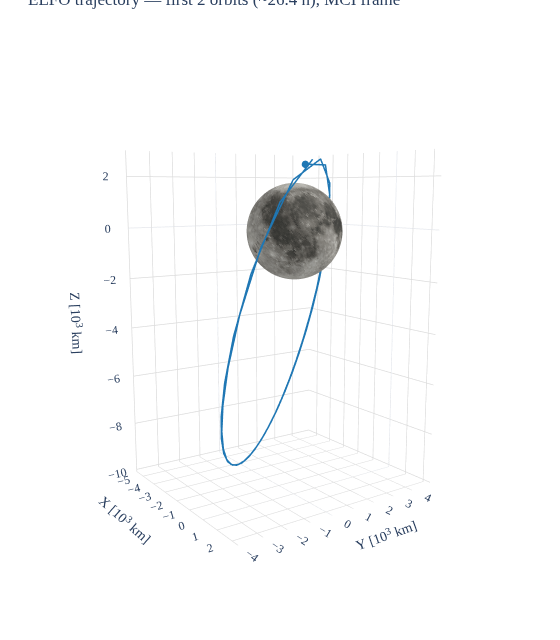

In [7]:
n_plot = int(np.ceil(2 * period / dt_out)) + 1  # two orbital periods

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON)
pnt.plot.plot_orbits(fig, rv_mci[:n_plot], t=0)
pnt.plot.set_view(fig, azimuth=-35, elevation=10, zoom=3)
fig.update_layout(
    width=560,
    height=560,
    title=f"ELFO trajectory — first 2 orbits (~{2 * period / pnt.SECS_HOUR:.1f} h), MCI frame",
)
embed_plotly(fig, "ex1_orbit")

## 7. Osculating orbital elements in the OP frame

The numerical integrator propagates Cartesian states in `MOON_CI`, but the frozen-orbit interpretation is clearest in the `MOON_OP` frame. We therefore rotate each state back into OP before extracting osculating elements.

An osculating element is the instantaneous Keplerian orbit that would match the current state if all perturbations were suddenly removed. Plotting these elements turns the Cartesian trajectory into physically interpretable quantities such as eccentricity, inclination, and argument of periapsis.

In [8]:
# Convert each MCI state to the OP frame, then extract osculating COE.
rv_op = np.array(
    [
        pnt.convert_frame(tfs[k], rv_mci[k], pnt.MOON_CI, pnt.MOON_OP)
        for k in range(len(tfs))
    ]
)
coe = np.array([pnt.cart_to_classical(rv_op[k], pnt.GM_MOON) for k in range(len(tfs))])
# columns: [a, e, i, RAAN, ω, M]  —  angles in radians, a in metres

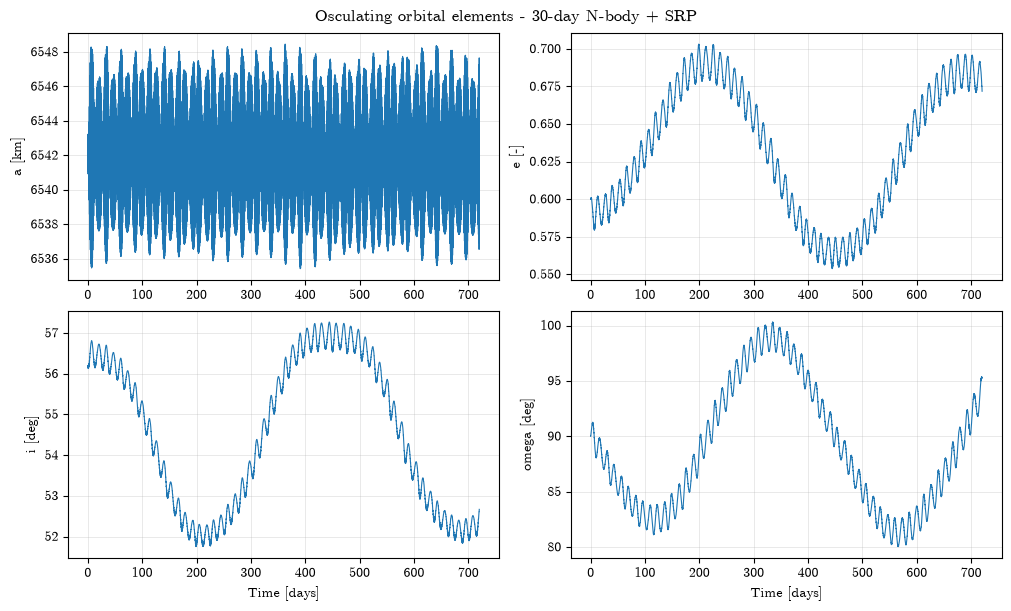

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
fig.suptitle("Osculating orbital elements - 30-day N-body + SRP")

axes[0, 0].plot(t_days, coe[:, 0] / 1e3, lw=0.8)
axes[0, 0].set_ylabel("a [km]")

axes[0, 1].plot(t_days, coe[:, 1], lw=0.8)
axes[0, 1].set_ylabel("e [-]")

axes[1, 0].plot(t_days, coe[:, 2] * pnt.DEG, lw=0.8)
axes[1, 0].set_ylabel("i [deg]")
axes[1, 0].set_xlabel("Time [days]")

axes[1, 1].plot(t_days, coe[:, 4] * pnt.DEG, lw=0.8)
axes[1, 1].set_ylabel("omega [deg]")
axes[1, 1].set_xlabel("Time [days]")

for ax in axes.flat:
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()

## 8. e-omega phase portrait

A frozen orbit does not mean the elements are perfectly constant. It means the perturbations make them librate around a stable equilibrium instead of circulating away. The $e$-$\omega$ phase portrait shows that behavior directly: the trajectory should remain near the nominal frozen point rather than drift monotonically.

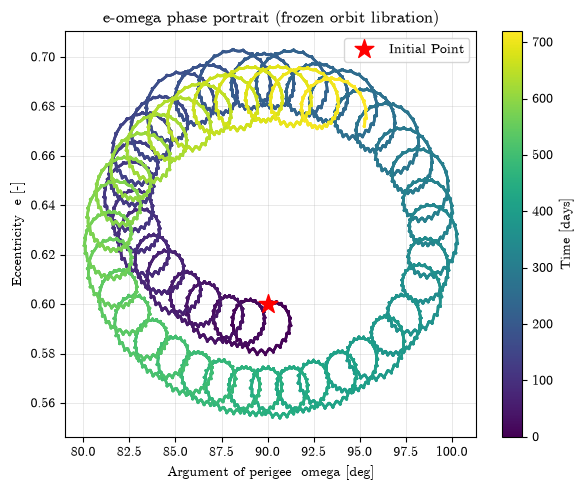

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    coe[:, 4] * pnt.DEG, coe[:, 1], c=t_days, cmap="viridis", s=4, lw=0, zorder=3
)
ax.plot(coe[:, 4] * pnt.DEG, coe[:, 1], lw=0.5, color="steelblue", alpha=0.35, zorder=2)

ax.scatter(
    [90.0], [0.6], marker="*", s=200, color="red", zorder=5, label="Initial Point"
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time [days]")

ax.set_xlabel("Argument of perigee  omega [deg]")
ax.set_ylabel("Eccentricity  e [-]")
ax.set_title("e-omega phase portrait (frozen orbit libration)")
ax.legend()
ax.grid(True, lw=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Acceleration budget by force term

The final diagnostic decomposes the total acceleration into its modeled pieces. This is a useful way to connect the code to the physics:

$$
\mathbf a_{total}=\mathbf a_{Moon\ gravity}+\mathbf a_{Earth}+\mathbf a_{Sun}+\mathbf a_{SRP}+\cdots
$$

With `decompose_gravity=True`, LuPNT reports individual spherical-harmonic contributions in addition to third-body, SRP, and relativistic terms. The returned components sum to the acceleration used by the propagator. We evaluate a higher-degree lunar gravity field over a short, fine-cadence arc so the per-orbit structure of the perturbations is visible.

In [11]:
# Higher-fidelity Moon field (8x8) so individual higher-order harmonics are resolved.
# (The long propagation above used a 2x2 field; here we want the full harmonic budget.)
dyn_hf = pnt.NBodyDynamics()
dyn_hf.set_frame(pnt.MOON_CI)
dyn_hf.set_units(pnt.SI_UNITS)
dyn_hf.add_body(pnt.create_body(pnt.MOON, 8, 8))  # 8x8 lunar gravity field
dyn_hf.add_body(pnt.create_body(pnt.EARTH))  # Earth third-body
dyn_hf.add_body(pnt.create_body(pnt.SUN))  # Sun third-body + SRP source
dyn_hf.set_srp_coeff(1.8, 0.02, 10.0)
dyn_hf.set_integrator(pnt.IntegratorType.RKF45)
dyn_hf.set_integrator_params(params)

# Restrict to the first few orbits, sampled finely to resolve the per-orbit variation.
n_orbits_acc = 3
dt_acc = period / 300.0  # [s] fine output cadence
tspan_acc = np.arange(0, n_orbits_acc * period, dt_acc)  # relative [s]
tfs_acc = t0 + tspan_acc  # absolute TAI [s]
t_hours = tspan_acc / pnt.SECS_HOUR

rv_acc = dyn_hf.propagate(rv0_mci, tfs_acc)  # [N x 6] MCI states

# Decompose the acceleration at each epoch. With decompose_gravity=True the lunar
# gravity field is split per spherical-harmonic term (MOON_J2, MOON_C22, ...).
acc_terms = {}  # term name -> [N, 3] acceleration array [m/s^2]
for k in range(len(tfs_acc)):
    for name, vec in dyn_hf.compute_accelerations(
        tfs_acc[k], rv_acc[k], decompose_gravity=True
    ).items():
        acc_terms.setdefault(name, np.zeros((len(tfs_acc), 3)))[k] = vec

# Magnitude of each contribution over time [m/s^2].
acc_mag = {name: np.linalg.norm(v, axis=1) for name, v in acc_terms.items()}

# Rank the terms by their peak magnitude over the window.
peak = {name: mag.max() for name, mag in acc_mag.items()}
ranked = sorted(peak, key=peak.get, reverse=True)
print("Force terms (by peak magnitude over the window):")
for name in ranked:
    print(f"  {name:16s} peak |a| = {peak[name]:.3e} m/s^2")

Force terms (by peak magnitude over the window):
  MOON_gravity     peak |a| = 7.193e-01 m/s^2
  MOON_J2          peak |a| = 1.556e-04 m/s^2
  EARTH_gravity    peak |a| = 1.082e-04 m/s^2
  MOON_C31         peak |a| = 5.005e-05 m/s^2
  MOON_C22         peak |a| = 2.687e-05 m/s^2
  MOON_C32         peak |a| = 1.633e-05 m/s^2
  MOON_C42         peak |a| = 1.254e-05 m/s^2
  MOON_C41         peak |a| = 1.090e-05 m/s^2
  MOON_C43         peak |a| = 9.487e-06 m/s^2
  MOON_C53         peak |a| = 7.103e-06 m/s^2
  MOON_C33         peak |a| = 6.790e-06 m/s^2
  MOON_C71         peak |a| = 5.696e-06 m/s^2
  MOON_C52         peak |a| = 5.668e-06 m/s^2
  MOON_C62         peak |a| = 5.322e-06 m/s^2
  MOON_J3          peak |a| = 4.773e-06 m/s^2
  MOON_C51         peak |a| = 3.868e-06 m/s^2
  MOON_C63         peak |a| = 3.847e-06 m/s^2
  MOON_J4          peak |a| = 3.700e-06 m/s^2
  MOON_J7          peak |a| = 2.963e-06 m/s^2
  MOON_C65         peak |a| = 2.951e-06 m/s^2
  MOON_C61         peak |a| = 2

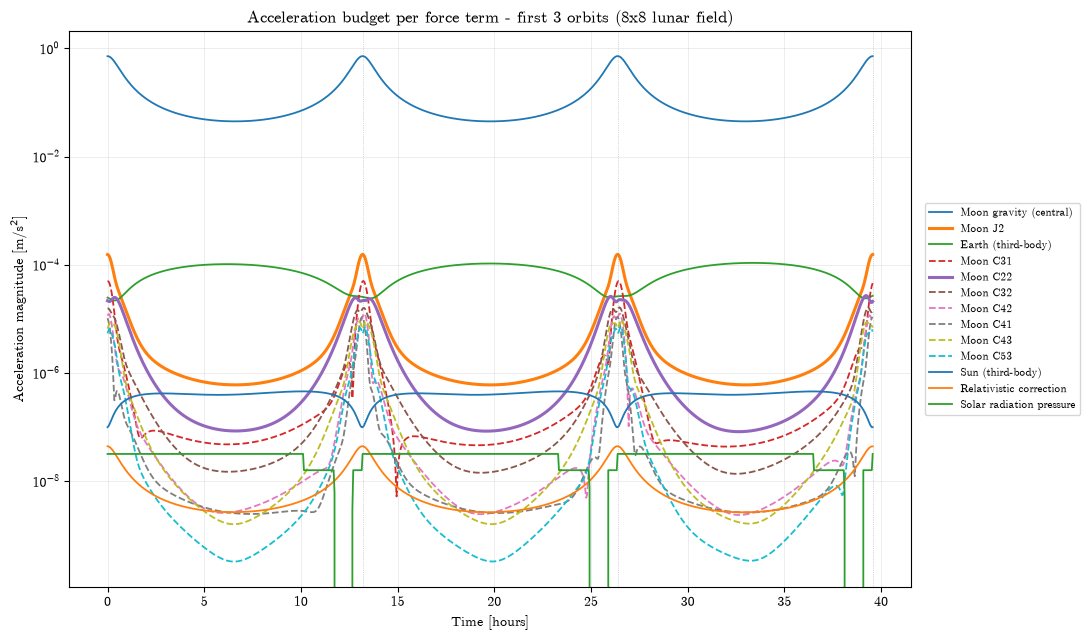

In [12]:
# Select which terms to draw: the central bodies/forces, the requested J2 & C22,
# plus the next-strongest higher-order lunar harmonics for context.
base_terms = ["MOON_gravity", "EARTH_gravity", "SUN_gravity", "srp", "relativity"]
key_harmonics = ["MOON_J2", "MOON_C22"]  # explicitly requested
other_harmonics = [
    n
    for n in ranked
    if n.startswith("MOON_") and n not in ("MOON_gravity",) + tuple(key_harmonics)
]
selected = (
    base_terms + key_harmonics + other_harmonics[:6]
)  # a few more higher-order terms
selected = [n for n in ranked if n in selected]  # keep strongest-first order

nice = {
    "MOON_gravity": "Moon gravity (central)",
    "EARTH_gravity": "Earth (third-body)",
    "SUN_gravity": "Sun (third-body)",
    "srp": "Solar radiation pressure",
    "relativity": "Relativistic correction",
}


def label_for(name):
    return nice.get(
        name, "Moon " + name.replace("MOON_", "")
    )  # e.g. "Moon J2", "Moon C22"


fig, ax = plt.subplots(figsize=(11, 6.5))
for name in selected:
    lw, ls = 1.3, "-"
    if name in key_harmonics:
        lw, ls = 2.2, "-"  # emphasize J2 and C22
    elif name.startswith("MOON_") and name != "MOON_gravity":
        ls = "--"  # other harmonics dashed
    ax.semilogy(t_hours, acc_mag[name], lw=lw, ls=ls, label=label_for(name))

# Mark orbital-period boundaries.
for k in range(1, n_orbits_acc + 1):
    ax.axvline(k * period / pnt.SECS_HOUR, color="gray", lw=0.5, ls=":", alpha=0.6)

ax.set_xlabel("Time [hours]")
ax.set_ylabel(r"Acceleration magnitude [m/s$^2$]")
ax.set_title(
    f"Acceleration budget per force term - first {n_orbits_acc} orbits (8x8 lunar field)"
)
ax.grid(True, which="both", lw=0.4, alpha=0.4)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()
plt.show()